In [1]:
import numpy as np               # numerical computing library
import matplotlib.pyplot as plt  # plotting library
import os                        # operating system interface

os.chdir(r'C:/Users/Giannis/.vscode/04_drone_pid_stabilizer')  # set working directory

In [ ]:
class PIDController:
    def __init__(self, Kp, Ki, Kd):
        """
        Kp = proportional gain → reacts to current error
        Ki = integral gain     → corrects accumulated drift over time
        Kd = derivative gain   → dampens rate of change
        """
        self.Kp = Kp            # proportional gain
        self.Ki = Ki            # integral gain
        self.Kd = Kd            # derivative gain
        self.integral = 0       # accumulated error over time — starts at zero
        self.last_error = None  # previous error — None until first compute call

    def compute(self, setpoint, measurement, dt):
        error = setpoint - measurement  # current error = target - actual angle

        self.integral += error * dt     # accumulate error over time (Ki term)

        if self.last_error is None:
            derivative = 0              # first step — no previous error to compare
        else:
            derivative = (error - self.last_error) / dt  # rate of error change (Kd term)

        self.last_error = error         # store current error for next step

        # PID output — weighted sum of three terms
        output = (self.Kp * error +          # proportional — reacts to current error
                  self.Ki * self.integral +  # integral — corrects long-term drift
                  self.Kd * derivative)      # derivative — dampens oscillation

        return output, error            # return correction and current error

In [ ]:
dt = 0.01                 # time step in seconds — small enough for accurate integration
t = np.arange(0, 15, dt)  # time array from 0 to 15 seconds
setpoint = 0.0            # target angle — we want the drone perfectly level
angle = 30.0              # initial tilt — drone starts at 30 degrees
velocity = 0.0          # initial angular velocity — drone starts stationary

# PID gains — tuned for clean convergence without overshoot

pid = PIDController(Kp=2.0, Ki=0.01, Kd=3.0)

angles = []    # store angle at each time step
errors = []    # store error at each time step
outputs = []   # store PID output at each time step

for _ in t:
    output, error = pid.compute(setpoint, angle, dt)  # compute PID correction

    velocity += output * dt   # apply correction to angular velocity
    velocity *= 0.95          # damping factor — simulates air resistance
    angle += velocity * dt    # update angle based on velocity

    angles.append(angle)      # record angle
    errors.append(error)      # record error
    outputs.append(output)    # record PID output

print(f'Final angle: {angles[-1]:.4f} degrees')  # should be close to 0

# find first time angle enters ±1° tolerance zone

settled = next((i for i, a in enumerate(angles) if abs(a) < 1), None)
if settled:
    print(f'Settled within 1° at t = {t[settled]:.2f}s')  # settling time
else:
    print(f'Did not settle within 1° — final angle: {angles[-1]:.2f}°')

Final angle: 0.1964 degrees
Settled within 1° at t = 12.15s


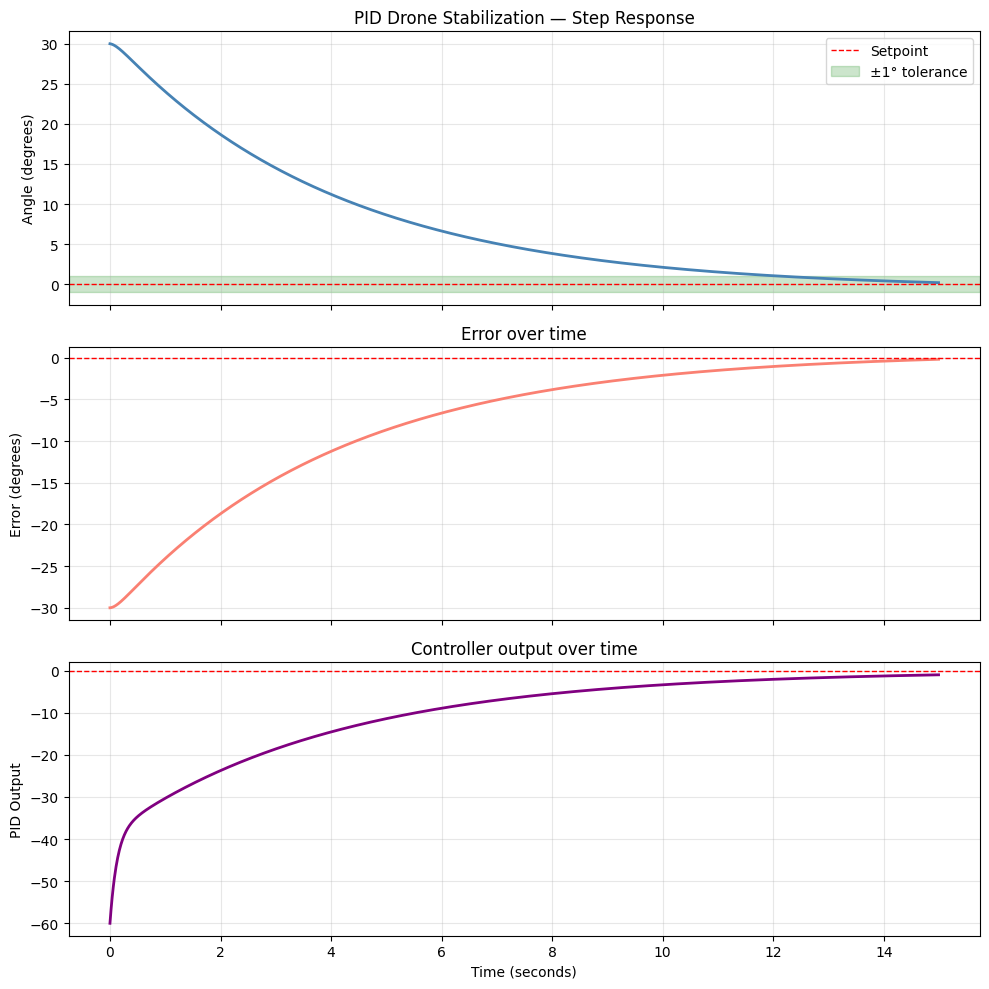

In [ ]:
# 3 subplots sharing x axis — angle, error and PID output over time

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# plot 1 — angle over time

axes[0].plot(t, angles, color='steelblue', linewidth=2)
axes[0].axhline(0, color='red', linestyle='--',
                linewidth=1, label='Setpoint')         # target angle line
axes[0].axhspan(-1, 1, alpha=0.2, color='green',
                label='±1° tolerance')                 # acceptable range
axes[0].set_ylabel('Angle (degrees)')
axes[0].set_title('PID Drone Stabilization — Step Response')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# plot 2 — error over time (mirrors angle since setpoint = 0)

axes[1].plot(t, errors, color='salmon', linewidth=2)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)  # zero error line
axes[1].set_ylabel('Error (degrees)')
axes[1].set_title('Error over time')
axes[1].grid(True, alpha=0.3)

# plot 3 — PID controller output over time

axes[2].plot(t, outputs, color='purple', linewidth=2)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)  # zero output line
axes[2].set_ylabel('PID Output')
axes[2].set_title('Controller output over time')
axes[2].grid(True, alpha=0.3)

plt.xlabel('Time (seconds)')   # shared x axis label
plt.tight_layout()             # auto adjust spacing
plt.savefig('results/01_pid_step_response.png', bbox_inches='tight')  # save
plt.show()